## Fuzzy Label Matching -- Diagnostic Analysis

## Disclaimer: This notebook was constructed with assistance from Gemini 3.1 Pro for code completion, debugging, and graph styling.

In [1]:
import os, re, json, glob, difflib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

INPUT_DIR = "unimodal/text_corruptions"
OUTPUT_DIR = "evaluation/textual/fuzzy"
os.makedirs(OUTPUT_DIR, exist_ok=True)

CORRUPTION_ORDER = [
    "fragmentation", "character_noise", "ata_saliency",
    "homophone", "synonym",
]
CORRUPTION_LABELS = [
    "Fragmentation", "Char. Noise", "Lexical Saliency",
    "Homophone", "Synonym",
]
GROUP_SPANS = {"Orthographic": (0, 2), "Semantic": (3, 4)}
GROUP_SEPS = [2.5]

In [2]:
def normalize_label(text):
    if not isinstance(text, str): return ""
    return re.sub(r'[\s\u200b\u200d]+', '', text).lower()

def extract_target_objects(prompt):
    if not prompt: return []
    m = re.search(r'objects "(.*?)"', prompt)
    return [normalize_label(x) for x in m.group(1).split(',')] if m else []

def extract_json_array(s):
    s = s.strip()
    a, b = s.find('['), s.rfind(']')
    if a == -1 or b == -1 or b < a: return []
    try: return json.loads(s[a:b+1])
    except json.JSONDecodeError: return []

def classify_match(p, t):
    """Returns (match_type, similarity_ratio)."""
    if p == t: return "exact", 1.0
    if sorted(p) == sorted(t):
        return "anagram", difflib.SequenceMatcher(None, p, t).ratio()
    r = difflib.SequenceMatcher(None, p, t).ratio()
    return ("threshold", r) if r >= 0.75 else ("none", r)

def analyze_one(gt_dict, result_str, corrupted_prompt):
    """Per-GT-object label-match analysis for a single corruption result."""
    preds = [p for p in extract_json_array(result_str)
             if isinstance(p, dict) and 'bbox_2d' in p]
    prompt_labels = extract_target_objects(corrupted_prompt)
    tp = {"exact": 0, "anagram": 1, "threshold": 2}
    rows = []

    for key in gt_dict:
        gt_label = key.split('_')[0]
        gt_norm = normalize_label(gt_label)
        gt_hits, pr_hits = [], []

        for p in preds:
            pn = normalize_label(p.get('label', ''))
            mt, mr = classify_match(pn, gt_norm)
            if mt != "none":
                gt_hits.append((mt, mr)); continue
            for pl in prompt_labels:
                mt2, mr2 = classify_match(pn, pl)
                if mt2 != "none":
                    pr_hits.append((mt2, mr2)); break

        bfr = 0.0
        if not gt_hits and not pr_hits and preds:
            for p in preds:
                pn = normalize_label(p.get('label', ''))
                for t in [gt_norm] + prompt_labels:
                    bfr = max(bfr, classify_match(pn, t)[1])

        if gt_hits:
            gt_hits.sort(key=lambda x: tp.get(x[0], 99))
            path, mtype, ratio = "gt", gt_hits[0][0], gt_hits[0][1]
        elif pr_hits:
            pr_hits.sort(key=lambda x: tp.get(x[0], 99))
            path, mtype, ratio = "prompt", pr_hits[0][0], pr_hits[0][1]
        elif not preds:
            path, mtype, ratio = "no_preds", "none", 0.0
        else:
            path, mtype, ratio = "label_mismatch", "none", 0.0

        rows.append(dict(
            gt_key=key, gt_label=gt_label,
            match_path=path, match_type=mtype,
            similarity_ratio=ratio,
            best_failing_ratio=bfr if path == "label_mismatch" else np.nan,
            n_preds=len(preds),
        ))
    return rows

In [3]:
files = sorted(glob.glob(os.path.join(INPUT_DIR, "**", "scale_*_TEXT.json"), recursive=True))
print(f"{len(files)} result files")

records = []
for fp in files:
    with open(fp, 'r', encoding='utf-8') as f:
        data = json.load(f)
    gt = data.get("ground_truth_bboxes", {})
    scale = data.get("corruption_scale", -1)
    for c_name, c_data in data.get("corruptions", {}).items():
        if c_name not in CORRUPTION_ORDER:
            continue
        for row in analyze_one(gt, c_data.get("result", ""), c_data.get("prompt", "")):
            row.update(corruption=c_name, scale=scale, file=fp, iou=c_data.get("IoU", np.nan))
            records.append(row)

df = pd.DataFrame(records)
df["corruption"] = pd.Categorical(df["corruption"], categories=CORRUPTION_ORDER, ordered=True)
print(f"{len(df)} GT-object records")

3750 result files
50475 GT-object records


In [4]:
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 140, "savefig.dpi": 220,
    "font.family": "sans-serif",
})

PATH_PALETTE = {"gt": "#2d6a4f", "prompt": "#457b9d", "label_mismatch": "#e76f51", "no_preds": "#adb5bd"}
PATH_ORDER   = ["gt", "prompt", "label_mismatch", "no_preds"]
PATH_LABELS  = ["GT path", "Prompt path", "Label mismatch", "No predictions"]

TYPE_PALETTE = {"exact": "#1b4332", "anagram": "#52b788", "threshold": "#d9ed92"}
TYPE_ORDER   = ["exact", "anagram", "threshold"]

def add_group_seps(ax):
    for s in GROUP_SEPS:
        ax.axhline(s, color="#bbb", lw=0.6, ls="-", zorder=0)

### 1 -- Match path distribution per corruption

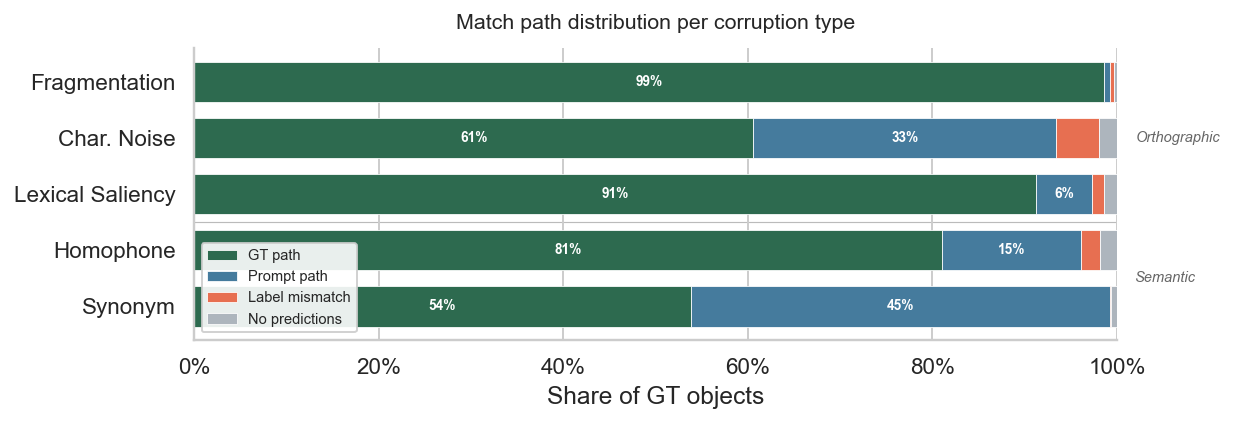

In [5]:
ct = (pd.crosstab(df["corruption"], df["match_path"], normalize="index")
        .reindex(columns=PATH_ORDER, fill_value=0))

fig, ax = plt.subplots(figsize=(9, 3.2))
left = np.zeros(len(ct))
y = np.arange(len(ct))

for col, color, label in zip(PATH_ORDER, [PATH_PALETTE[k] for k in PATH_ORDER], PATH_LABELS):
    vals = ct[col].values
    ax.barh(y, vals, left=left, color=color, label=label, height=0.72, edgecolor="white", lw=0.4)
    for i, (v, l) in enumerate(zip(vals, left)):
        if v > 0.05:
            ax.text(l + v/2, i, f"{v:.0%}", ha="center", va="center",
                    fontsize=7, color="white", fontweight="bold")
    left += vals

ax.set_yticks(y)
ax.set_yticklabels(CORRUPTION_LABELS)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Share of GT objects")
ax.legend(loc="lower left", fontsize=7.5, framealpha=0.9)
ax.invert_yaxis()
add_group_seps(ax)

for name, (lo, hi) in GROUP_SPANS.items():
    ax.text(1.02, (lo + hi) / 2, name, ha="left", va="center",
            fontsize=7.5, fontstyle="italic", color="#666",
            transform=ax.get_yaxis_transform())

ax.set_title("Match path distribution per corruption type", fontsize=11, pad=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fuzzy_match_path_distribution.pdf"), bbox_inches="tight")
plt.savefig(os.path.join(OUTPUT_DIR, "fuzzy_match_path_distribution.png"), bbox_inches="tight")
plt.show()

### 3 -- Match type within GT-path matches

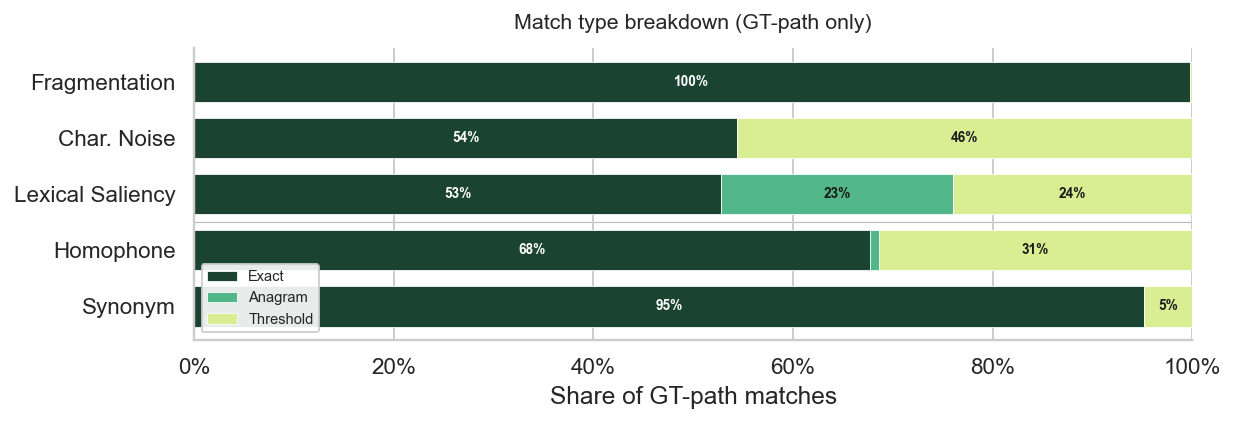

In [6]:
gt_df = df[df["match_path"] == "gt"]
ct_gt = (pd.crosstab(gt_df["corruption"], gt_df["match_type"], normalize="index")
           .reindex(columns=TYPE_ORDER, fill_value=0)
           .reindex(CORRUPTION_ORDER))

fig, ax = plt.subplots(figsize=(9, 3.2))
left = np.zeros(len(ct_gt))
y = np.arange(len(ct_gt))

for col, color in zip(TYPE_ORDER, [TYPE_PALETTE[k] for k in TYPE_ORDER]):
    vals = ct_gt[col].values
    tc = "white" if col == "exact" else "#1b1b1b"
    ax.barh(y, vals, left=left, color=color, label=col.capitalize(),
            height=0.72, edgecolor="white", lw=0.4)
    for i, (v, l) in enumerate(zip(vals, left)):
        if v > 0.04:
            ax.text(l + v/2, i, f"{v:.0%}", ha="center", va="center",
                    fontsize=7, color=tc, fontweight="bold")
    left += vals

ax.set_yticks(y)
ax.set_yticklabels(CORRUPTION_LABELS)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Share of GT-path matches")
ax.legend(loc="lower left", fontsize=7.5, framealpha=0.9)
ax.invert_yaxis()
add_group_seps(ax)
ax.set_title("Match type breakdown (GT-path only)", fontsize=11, pad=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fuzzy_gt_path_types.pdf"), bbox_inches="tight")
plt.savefig(os.path.join(OUTPUT_DIR, "fuzzy_gt_path_types.png"), bbox_inches="tight")
plt.show()

### 4 -- Near-miss analysis

### Summary

In [7]:
def agg(g):
    gt   = (g["match_path"] == "gt").sum()
    pr   = (g["match_path"] == "prompt").sum()
    np_  = (g["match_path"] == "no_preds").sum()
    lm   = (g["match_path"] == "label_mismatch").sum()
    m    = gt + pr
    fz   = g["match_type"].isin(["anagram", "threshold"]).sum()
    return pd.Series({
        "N":          len(g),
        "GT path":    gt,
        "Prompt":     pr,
        "No preds":   np_,
        "Lbl miss":   lm,
        "Fuzzy":      fz,
        "Fuzzy %":    f"{fz/m:.1%}" if m else "--",
    })

tbl = df.groupby("corruption", observed=True).apply(agg, include_groups=False).reindex(CORRUPTION_ORDER)
tbl.index = CORRUPTION_LABELS
tbl

,N,GT path,Prompt,No preds,Lbl miss,Fuzzy,Fuzzy %
Fragmentation,10095,9951,65,35,44,60,0.6%
Char. Noise,10095,6114,3318,192,471,3168,33.6%
Lexical Saliency,10095,9212,606,145,132,4446,45.3%
Homophone,10095,8184,1514,189,208,2735,28.2%
Synonym,10095,5431,4583,61,20,277,2.8%


In [8]:
syn = df[(df["corruption"] == "synonym") & (df["match_path"] == "gt")].copy()

examples = []
for _, row in syn.iterrows():
    with open(row["file"], 'r', encoding='utf-8') as f:
        data = json.load(f)
    c = data["corruptions"]["synonym"]
    prompt_labels = extract_target_objects(c["prompt"])
    for pred in extract_json_array(c["result"]):
        if not isinstance(pred, dict) or "bbox_2d" not in pred:
            continue
        pn = normalize_label(pred.get("label", ""))
        gn = normalize_label(row["gt_label"])
        mt, _ = classify_match(pn, gn)
        if mt != "none":
            examples.append({
                "gt_label": row["gt_label"],
                "prompted_as": ", ".join(prompt_labels),
                "vlm_returned": pred.get("label", ""),
                "match_type": mt,
                "scale": row["scale"],
            })
            break  # one per GT object

ex_df = pd.DataFrame(examples)
print(f"{len(ex_df)} GT-path synonym hits\n")

corrected = ex_df[ex_df.apply(
    lambda r: normalize_label(r["vlm_returned"]) != normalize_label(r["prompted_as"].split(",")[0]),
    axis=1
)]
print(f"{len(corrected)} of those returned a label different from the prompted synonym:\n")
display(corrected.value_counts(["prompted_as", "vlm_returned", "gt_label"]).reset_index(name="count")
        .sort_values("count", ascending=False).head(30))

5431 GT-path synonym hits

1666 of those returned a label different from the prompted synonym:



,prompted_as,vlm_returned,gt_label,count
0,"dog, person",person,person,24
1,"cattle, hatwithawidebrim, helmet, person",hat with a wide brim,hat with a wide brim,20
2,"bowl, orange",orange,orange,20
3,"chair, dog",dog,dog,20
4,"cattle, hatwithawidebrim, helmet, person",person,person,20
5,"neckbrace, person",person,person,19
6,"person, watercraft",watercraft,watercraft,19
7,"rucksack, person",person,person,18
8,"backpack, person",person,person,17
9,"helmet, person, watercraft",watercraft,watercraft,15


In [9]:
homo = df[(df["corruption"] == "homophone") & (df["match_path"] == "gt")].copy()

thresh = homo[homo["match_type"] == "threshold"]
anag = homo[homo["match_type"] == "anagram"]
print(f"Homophone GT-path: {len(homo)} total | {len(thresh)} threshold | {len(anag)} anagram\n")

def collect_examples(subset, label):
    examples = []
    for _, row in subset.iterrows():
        with open(row["file"], 'r', encoding='utf-8') as f:
            data = json.load(f)
        c = data["corruptions"]["homophone"]
        orig_labels = extract_target_objects(data["original_prompt"])
        corr_labels = extract_target_objects(c["prompt"])
        gn = normalize_label(row["gt_label"])

        for orig, corr in zip(orig_labels, corr_labels):
            if classify_match(orig, gn)[0] != "none":
                mt_corr, ratio_corr = classify_match(corr, gn)
                examples.append({
                    "gt_label": row["gt_label"],
                    "original": orig,
                    "homophone": corr,
                    "was_corrupted": orig != corr,
                    "match_vs_gt": mt_corr,
                    "ratio_vs_gt": round(ratio_corr, 4),
                    "scale": row["scale"],
                })
                break
    return pd.DataFrame(examples)

print("=== THRESHOLD (≥0.75) ===")
t_df = collect_examples(thresh, "threshold")
print(f"Was actually corrupted: {t_df['was_corrupted'].sum()} / {len(t_df)}\n")
print("Top corrupted pairs (homophone close enough to GT for threshold):")
display(t_df[t_df["was_corrupted"]]
        .value_counts(["gt_label", "homophone", "ratio_vs_gt"])
        .reset_index(name="count")
        .sort_values("count", ascending=False).head(20))

print(f"\nUncorrupted (should be 0): {(~t_df['was_corrupted']).sum()}")

print("\n=== ANAGRAM ===")
a_df = collect_examples(anag, "anagram")
print(f"Was actually corrupted: {a_df['was_corrupted'].sum()} / {len(a_df)}\n")
if len(a_df) > 0:
    print("Pairs where homophone is an anagram of GT:")
    display(a_df.value_counts(["gt_label", "homophone", "ratio_vs_gt"])
            .reset_index(name="count")
            .sort_values("count", ascending=False).head(20))

Homophone GT-path: 8184 total | 2572 threshold | 72 anagram

=== THRESHOLD (≥0.75) ===
Was actually corrupted: 2559 / 2572

Top corrupted pairs (homophone close enough to GT for threshold):


,gt_label,homophone,ratio_vs_gt,count
0,bird,berd,0.7500,172
1,person,purseon,0.7692,151
2,bird,byrd,0.7500,119
3,person,pearson,0.9231,111
4,dog,dogg,0.8571,82
5,dog,doug,0.8571,77
6,person,persen,0.8333,67
7,bird,burd,0.7500,47
8,chair,chare,0.8000,34
9,bird,bard,0.7500,31



Uncorrupted (should be 0): 13

=== ANAGRAM ===
Was actually corrupted: 72 / 72

Pairs where homophone is an anagram of GT:


,gt_label,homophone,ratio_vs_gt,count
0,table,tabel,0.8000,26
1,snake,sneak,0.8000,18
2,apple,appel,0.8000,11
3,pretzel,pretzle,0.8571,6
4,bagel,bagle,0.8000,3
5,sheep,shepe,0.8000,3
6,pineapple,pineappel,0.8889,2
7,hat with a wide brim,hatwithawiedbrim,0.9375,1
8,cattle,cattel,0.8333,1
9,flute,fleut,0.8000,1


In [10]:
ct_raw = pd.crosstab(df["corruption"], df["match_path"]).reindex(columns=PATH_ORDER, fill_value=0)
ct_pct = pd.crosstab(df["corruption"], df["match_path"], normalize="index").reindex(columns=PATH_ORDER, fill_value=0)

combined = ct_raw.copy().astype(str)
for col in PATH_ORDER:
    combined[col] = ct_raw[col].apply(lambda x: f"{x:,}") + " (" + ct_pct[col].apply(lambda x: f"{x:.1%}") + ")"

combined.columns = PATH_LABELS
combined.index = CORRUPTION_LABELS
display(combined)

header = "| Corruption | " + " | ".join(PATH_LABELS) + " |"
sep = "|---|" + "|".join(["---:" for _ in PATH_LABELS]) + "|"
print(header)
print(sep)
for idx in combined.index:
    row = "| " + idx + " | " + " | ".join(combined.loc[idx]) + " |"
    print(row)

,GT path,Prompt path,Label mismatch,No predictions
Fragmentation,"9,951 (98.6%)",65 (0.6%),44 (0.4%),35 (0.3%)
Char. Noise,"6,114 (60.6%)","3,318 (32.9%)",471 (4.7%),192 (1.9%)
Lexical Saliency,"9,212 (91.3%)",606 (6.0%),132 (1.3%),145 (1.4%)
Homophone,"8,184 (81.1%)","1,514 (15.0%)",208 (2.1%),189 (1.9%)
Synonym,"5,431 (53.8%)","4,583 (45.4%)",20 (0.2%),61 (0.6%)


| Corruption | GT path | Prompt path | Label mismatch | No predictions |
|---|---:|---:|---:|---:|
| Fragmentation | 9,951 (98.6%) | 65 (0.6%) | 44 (0.4%) | 35 (0.3%) |
| Char. Noise | 6,114 (60.6%) | 3,318 (32.9%) | 471 (4.7%) | 192 (1.9%) |
| Lexical Saliency | 9,212 (91.3%) | 606 (6.0%) | 132 (1.3%) | 145 (1.4%) |
| Homophone | 8,184 (81.1%) | 1,514 (15.0%) | 208 (2.1%) | 189 (1.9%) |
| Synonym | 5,431 (53.8%) | 4,583 (45.4%) | 20 (0.2%) | 61 (0.6%) |
